# Source: [Microsoft Learn](https://learn.microsoft.com/)

# Clustering Challenge

Clustering is an *unsupervised* machine learning technique in which you train a model to group similar entities into clusters based on their features.

In this exercise, you must separate a dataset consisting of three numeric features (**A**, **B**, and **C**) into clusters. Run the cell below to load the data.

In [1]:
import pandas as pd

data = pd.read_csv('data/clusters.csv')
data.head()

,A,B,C
0,-0.087492,0.398000,0.014275
1,-1.071705,-0.546473,0.072424
2,2.747075,2.012649,3.083964
3,3.217913,2.213772,4.260312
4,-0.607273,0.793914,-0.516091


Your challenge is to identify the number of discrete clusters present in the data, and create a clustering model that separates the data into that number of clusters. You should also visualize the clusters to evaluate the level of separation achieved by your model.

Add markdown and code cells as required to create your solution.

> **Note**: There is no single "correct" solution.

# 1. Finding the number of clusters first

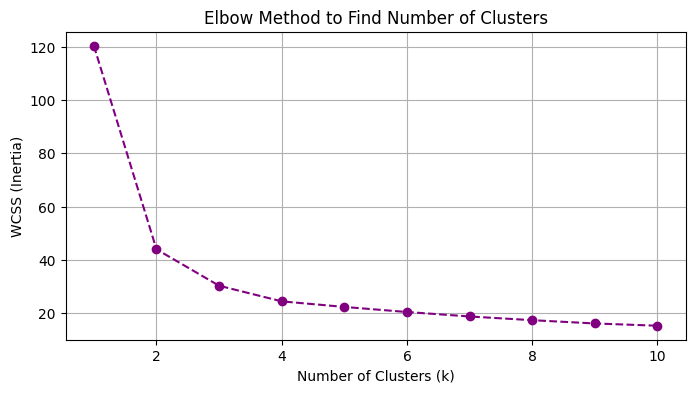

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler 

# features
X = data[['A', 'B', 'C']]

# we scale here the features using MinMaxScaler (bounds data between 0 and 1)
scaler = MinMaxScaler()  
X_scaled = scaler.fit_transform(X)

#Calculated inertia for different numbers of clusters
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='purple', linestyle='--')
plt.title('Elbow Method to Find Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

* **Optimal Cluster Identification**: Used the Elbow Method to plot Within-Cluster Sum of Squares (WCSS), identifying a distinct bend at $k=3$ as the ideal number of groupings.

# 2. Creating a clustering model (K-means Clustering)

In [8]:
from sklearn.cluster import KMeans

# Create a model based on 3 centroids
model = KMeans(n_clusters=3, init="k-means++", n_init=100, max_iter=1000)
km_clusters = model.fit_predict(X_scaled)
km_clusters


array([0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 1, 2, 0, 2, 1, 2, 1, 2, 2, 2, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 2, 0, 0, 1, 2, 2, 0, 2, 1, 0, 2, 2, 2, 1, 2,
       1, 0, 0, 1, 1, 2, 0, 2, 1, 1, 1, 1, 2, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 2, 1, 0, 2,
       2, 2, 0, 0, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 0, 2, 0, 1, 2, 2, 1,
       2, 2, 0, 0, 0, 1, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 2, 1, 1, 0, 2, 2,
       2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 2, 1, 2, 0,
       2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 2, 2, 0, 2, 2, 1, 2, 2, 2,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 2, 0, 1, 2, 1, 1, 0, 1,
       1, 0, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 1, 2,
       1, 2, 1, 0, 1, 0, 0, 2, 1, 1, 2, 0, 1, 1, 1, 0, 1, 0, 2, 1, 1, 2,
       0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 0, 0, 0, 1,
       1, 2, 1, 0, 0, 2, 0, 1, 1, 1, 2, 2, 2, 0, 1,

# 3. Visualize the clusters
visualize the clusters to evaluate the level of separation achieved by your model.

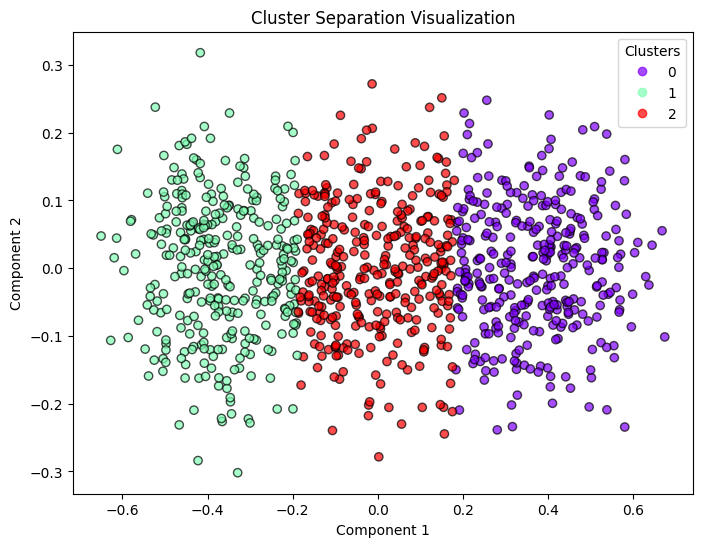

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce features from 3D to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# scatter plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=km_clusters,
    cmap="rainbow",
    alpha=0.7,
    edgecolors="black",
)

plt.title("Cluster Separation Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


* **Visual Verification**: The 2D PCA projection confirms that the trained model successfully separated the data into three well-defined, distinct clusters with clear boundaries.